---
title: "Encoder-Decoder Transformers: Sequence to Sequence, Variable Output Length"
description: |
  The second half of week 3. A decoder that emits digits until it emits an end token, trained by
  teacher forcing and scored on whether the whole sequence is right.
author: Rosh Beed
date: '2026-06-25'
categories:
  - vision
  - transformers
  - week-3
jupyter: python3
---


The second half of week 3. The [classifier](../2026-06-22-vision-transformers/)
looks at one digit and picks one of ten labels. This one reads a whole number.

The difference between the two is larger than it looks. A
classifier produces a fixed-size answer: ten scores, pick the biggest. Reading
produces an ordered sequence whose length the model has to decide, which means
something has to say where it stops.

![](figures/transformer.png){fig-alt="The full encoder-decoder: a three-digit image through linear projection of flattened patches into a stack of encoder blocks, the encoder output feeding decoder blocks alongside the tokens generated so far, producing 7 7 6 9 and then a finish token."}

The encoder is unchanged from the classifier. Everything new is on the right-hand
side.

## What a Decoder Adds

**A start token.** The decoder generates one position at a time, each conditioned
on what came before. At the first step there is no "before", so you feed it a
token that means *begin*.

**A causal mask.** During training the decoder sees the whole target sequence at
once, for speed. But position 2 must not see position 3. Otherwise the model learns
to read the answer it is being asked to predict.

At inference the future genuinely is not there, so a model trained that way
produces nothing useful. The mask stops it: each position sees only itself and
everything to its left.

**Cross-attention.** The decoder needs to look at the image. Self-attention lets
the output positions look at each other; cross-attention lets each output position
query the encoder's patch tokens and pull in what it needs.

And then an **end token**, so the model can say it's done. In a task whose answers
vary in length, that is what makes the length the model's decision rather than a
hyperparameter.

The canvas here is always the same width, but between one and three digits are
drawn on it and the rest is left blank. So the end token carries real weight: the
model has to decide how many digits it saw, and a read counts as correct only if
the digits are right *and* it stops in the right place. A three-digit answer to a
two-digit image is wrong however good the digits are.

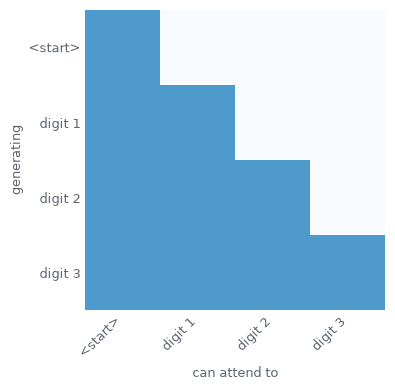

In [1]:
#| label: fig-mask
#| fig-cap: The causal mask. A filled cell means that output position is allowed to attend to that one; the blank upper triangle is the future, hidden.
#| fig-alt: A four-by-four grid where the lower triangle including the diagonal is filled and the upper triangle is blank.

# Setup, inlined rather than imported so this notebook runs on its own.
# Keep it folded; nothing below it depends on anything outside this file.

import torch.nn as nn
import visualtorch
import matplotlib.pyplot as plt

# --- chart styling -------------------------------------------------------
# Categorical slots of a CVD-validated palette: blue, orange, aqua, purple.
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#8a63d2"]
MUTED, GRID, AXIS = "#5b6570", "#e6e6e3", "#d5d5d1"


def style_axes(ax, xlabel=None, ylabel=None, grid="y"):
    """Strip an axes back to the ink that carries information."""
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    return ax


def figure(width=7.0, height=4.2, **kw):
    fig, ax = plt.subplots(figsize=(width, height), **kw)
    return fig, ax

# --- visualtorch, configured ---------------------------------------------
# Dropout is hidden: nn.TransformerEncoderLayer exposes its internal Dropout as a
# traceable leaf, every model here builds it with dropout=0.0, and drawing a no-op
# layer says it is part of the architecture when it is not. Uncoloured it also took
# visualtorch's default orange, near enough to MultiheadAttention's to be confusing.
COLOUR_MAP = {
    nn.Linear: {"fill": COLOURS[0]},
    nn.MultiheadAttention: {"fill": COLOURS[1]},
    nn.Embedding: {"fill": COLOURS[3]},
    nn.LayerNorm: {"fill": "#aeb6bf"},
    nn.GELU: {"fill": COLOURS[2]},
    nn.ReLU: {"fill": COLOURS[2]},
    nn.Flatten: {"fill": "#aeb6bf"},
    nn.Dropout: {"fill": "#e6e6e3"},
}
_COMMON = dict(color_map=COLOUR_MAP, connector_fill="#c3c9d0", background_fill="white",
               font_color=MUTED, legend=True, show_dimension=True,
               type_ignore=[nn.Dropout])


def diagram(model, input_shape, style="graph", **overrides):
    """Render `model` as a PIL image in this site's colours.

    `graph` draws real neurons and suits a short stack; `flow` draws volumetric
    blocks whose size tracks the layer's and stays readable on a deep one. `flow`
    reports a 3-D activation as (1, 1, width), losing the sequence length, so its
    shape labels are off. `level_gap=1` keeps a residual connection drawn close to
    the blocks it skips.
    """
    if style == "graph":
        settings = dict(node_size=24, layer_spacing=110, node_spacing=8,
                        ellipsize_after=5, **_COMMON)
    else:
        settings = dict(spacing=26, scale_xy=2.4, max_xy=280, one_dim_orientation="y",
                        level_gap=1, **_COMMON)
        settings["show_dimension"] = False
    settings.update(overrides)
    return visualtorch.render(model, input_shape=input_shape, style=style, **settings)


import matplotlib.pyplot as plt
import numpy as np
import torch

# Re-running this page must reproduce it, so a result that shifts between runs would let
# the prose and the output disagree. Torch's multithreaded CPU reductions add floats
# in whatever order the threads finish in; over a training loop that compounds into a
# different model. One thread makes the run reproducible.
torch.set_num_threads(1)

L = 3
labels = ["<start>", "digit 1", "digit 2", "digit 3"]
mask = np.tril(np.ones((L + 1, L + 1)))

fig, ax = plt.subplots(figsize=(4.4, 4.0))
ax.imshow(mask, cmap="Blues", vmin=0, vmax=1.7)
ax.set_xticks(range(L + 1), labels, rotation=45, ha="right")
ax.set_yticks(range(L + 1), labels)
ax.set_xlabel("can attend to", color=MUTED, fontsize=9)
ax.set_ylabel("generating", color=MUTED, fontsize=9)
ax.tick_params(colors=MUTED, labelsize=9, length=0)
for s in ax.spines.values():
    s.set_visible(False)
fig.tight_layout()


## Teacher Forcing

There's a subtlety in how this gets trained that took me a while to appreciate.

During training the decoder is fed the **true** previous digits at every position.
That's called teacher forcing, and it's what lets the whole sequence be computed
in one pass instead of three.

At inference there are no true previous digits. The model is fed **its own**
previous outputs. So if it gets digit 1 wrong, digit 2 is being predicted from a
prefix that never occurred during training.

So the training loss systematically flatters the model. The honest measure is
generating the whole sequence the way you actually would.

That is the number reported below. Guessing has to get both the digits and the
length right, which is why chance sits near one in thirty rather than one in a
thousand.

In [2]:
#| warning: false

import torch.nn as nn
from huggingface_hub import hf_hub_download

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

REVISION = "6bbb59474efaf5edfb62408686909305dbd45335"
data = np.load(hf_hub_download("roshbeed/ai-residency-blog-data", "mnist/mnist-full.npz",
                               repo_type="dataset", revision=REVISION))

x_train = torch.from_numpy(data["x_train"]).float() / 255.0
y_train = torch.from_numpy(data["y_train"]).long()
x_test = torch.from_numpy(data["x_test"]).float() / 255.0
y_test = torch.from_numpy(data["y_test"]).long()

START, END, PAD = 10, 11, 12   # three entries alongside the ten digits
VOCAB = 13


def compose(images, labels, n, seed):
    """One to three digits on a 28x84 canvas, left-aligned, the rest left blank.

    The canvas is always the same size. How much of it is occupied is not, which
    is the whole point: the model has to decide how many digits to emit.
    """
    rng = np.random.default_rng(seed)
    counts = torch.from_numpy(rng.integers(1, L + 1, n))
    pick = torch.from_numpy(rng.integers(0, len(images), (n, L)))
    present = torch.arange(L).unsqueeze(0) < counts.unsqueeze(1)

    tiles = images[pick] * present.unsqueeze(-1).unsqueeze(-1)
    canvas = torch.cat([tiles[:, slot] for slot in range(L)], dim=2)
    digits = torch.where(present, labels[pick], torch.full_like(labels[pick], PAD))
    return canvas, digits, counts


def teacher_pair(digits, counts):
    """`<start> d1 d2` in, `d1 d2 <end>` out, padded to the same width."""
    rows = len(digits)
    given = torch.cat([torch.full((rows, 1), START), digits], dim=1)
    wanted = torch.full((rows, L + 1), PAD, dtype=torch.long)
    wanted[:, :L] = digits
    wanted[torch.arange(rows), counts] = END
    return given, wanted


X, Y, counts_train = compose(x_train, y_train, 60_000, seed=0)
X_test, Y_test, counts_test = compose(x_test, y_test, 10_000, seed=1)
decoder_input, decoder_target = teacher_pair(Y, counts_train)
_, target_test = teacher_pair(Y_test, counts_test)

X, Y = X.to(DEVICE), Y.to(DEVICE)
X_test, Y_test = X_test.to(DEVICE), Y_test.to(DEVICE)
decoder_input, decoder_target = decoder_input.to(DEVICE), decoder_target.to(DEVICE)
target_test, counts_test = target_test.to(DEVICE), counts_test.to(DEVICE)

spread = torch.bincount(counts_train, minlength=L + 1)[1:]
chance = sum((spread[k - 1] / len(X)).item() * 10 ** -k for k in range(1, L + 1))
print(f"{len(X):,} composites of shape {tuple(X.shape[1:])}")
print(f"digits per image: " + ", ".join(f"{k}: {spread[k-1]:,}" for k in range(1, L + 1)))
print(f"guessing digits and length uniformly: {chance:.4f} exact-sequence accuracy")

/Users/rosh/mlx/roshbeed.github.io/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


60,000 composites of shape (28, 84), targets of length 3
guessing three digits uniformly: 0.0010 exact-sequence accuracy


In [3]:
PATCH, DIM, HEADS, LAYERS = 7, 256, 8, 6
GRID = (28 // PATCH, 84 // PATCH)          # 4 rows, 12 columns of patches
PATCHES = GRID[0] * GRID[1]

def patchify(images):
    batch = images.shape[0]
    return images.unfold(1, PATCH, PATCH).unfold(2, PATCH, PATCH).reshape(batch, PATCHES, PATCH**2)

class EncoderBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.attention = nn.MultiheadAttention(DIM, HEADS, batch_first=True)
        self.norm1, self.norm2 = nn.LayerNorm(DIM), nn.LayerNorm(DIM)
        self.ff = nn.Sequential(nn.Linear(DIM, 4 * DIM), nn.GELU(), nn.Linear(4 * DIM, DIM))

    def forward(self, x):
        x = self.norm1(x + self.attention(x, x, x, need_weights=False)[0])
        return self.norm2(x + self.ff(x))

class DecoderBlock(nn.Module):
    """Masked self-attention, then cross-attention onto the image, then a feed-forward."""

    def __init__(self):
        super().__init__()
        self.self_attention = nn.MultiheadAttention(DIM, HEADS, batch_first=True)
        self.cross_attention = nn.MultiheadAttention(DIM, HEADS, batch_first=True)
        self.norm1, self.norm2, self.norm3 = (nn.LayerNorm(DIM) for _ in range(3))
        self.ff = nn.Sequential(nn.Linear(DIM, 4 * DIM), nn.GELU(), nn.Linear(4 * DIM, DIM))

    def forward(self, x, memory, mask, want_weights=False):
        x = self.norm1(x + self.self_attention(x, x, x, attn_mask=mask, need_weights=False)[0])
        attended, weights = self.cross_attention(x, memory, memory,
                                                 need_weights=want_weights,
                                                 average_attn_weights=True)
        x = self.norm2(x + attended)
        return self.norm3(x + self.ff(x)), weights

In [4]:
class Reader(nn.Module):
    def __init__(self):
        super().__init__()
        self.project = nn.Linear(PATCH**2, DIM)
        self.image_positions = nn.Parameter(torch.randn(1, PATCHES, DIM) * 0.02)
        self.encoder = nn.ModuleList([EncoderBlock() for _ in range(LAYERS)])

        self.embed = nn.Embedding(VOCAB, DIM)   # ten digits, <start>, <end>, <pad>
        self.token_positions = nn.Parameter(torch.randn(1, L + 1, DIM) * 0.02)
        self.decoder = nn.ModuleList([DecoderBlock() for _ in range(LAYERS)])
        self.out = nn.Linear(DIM, VOCAB)

    def encode(self, images):
        h = self.project(patchify(images)) + self.image_positions
        for block in self.encoder:
            h = block(h)
        return h

    def decode(self, memory, tokens, want_weights=False):
        h = self.embed(tokens) + self.token_positions[:, :tokens.shape[1]]
        mask = torch.triu(torch.full((tokens.shape[1],) * 2, float("-inf"),
                                    device=tokens.device), diagonal=1)

        weights = None
        for i, block in enumerate(self.decoder):
            h, w = block(h, memory, mask, want_weights and i == LAYERS - 1)
            if w is not None:
                weights = w
        return self.out(h), weights

    def forward(self, images, tokens):
        return self.decode(self.encode(images), tokens)[0]

One in a thousand is the bar. Anything above it is the model reading rather than
guessing.

Both halves together. The image enters top left. The tokens enter bottom left
through their embedding. The two streams meet in the decoder.

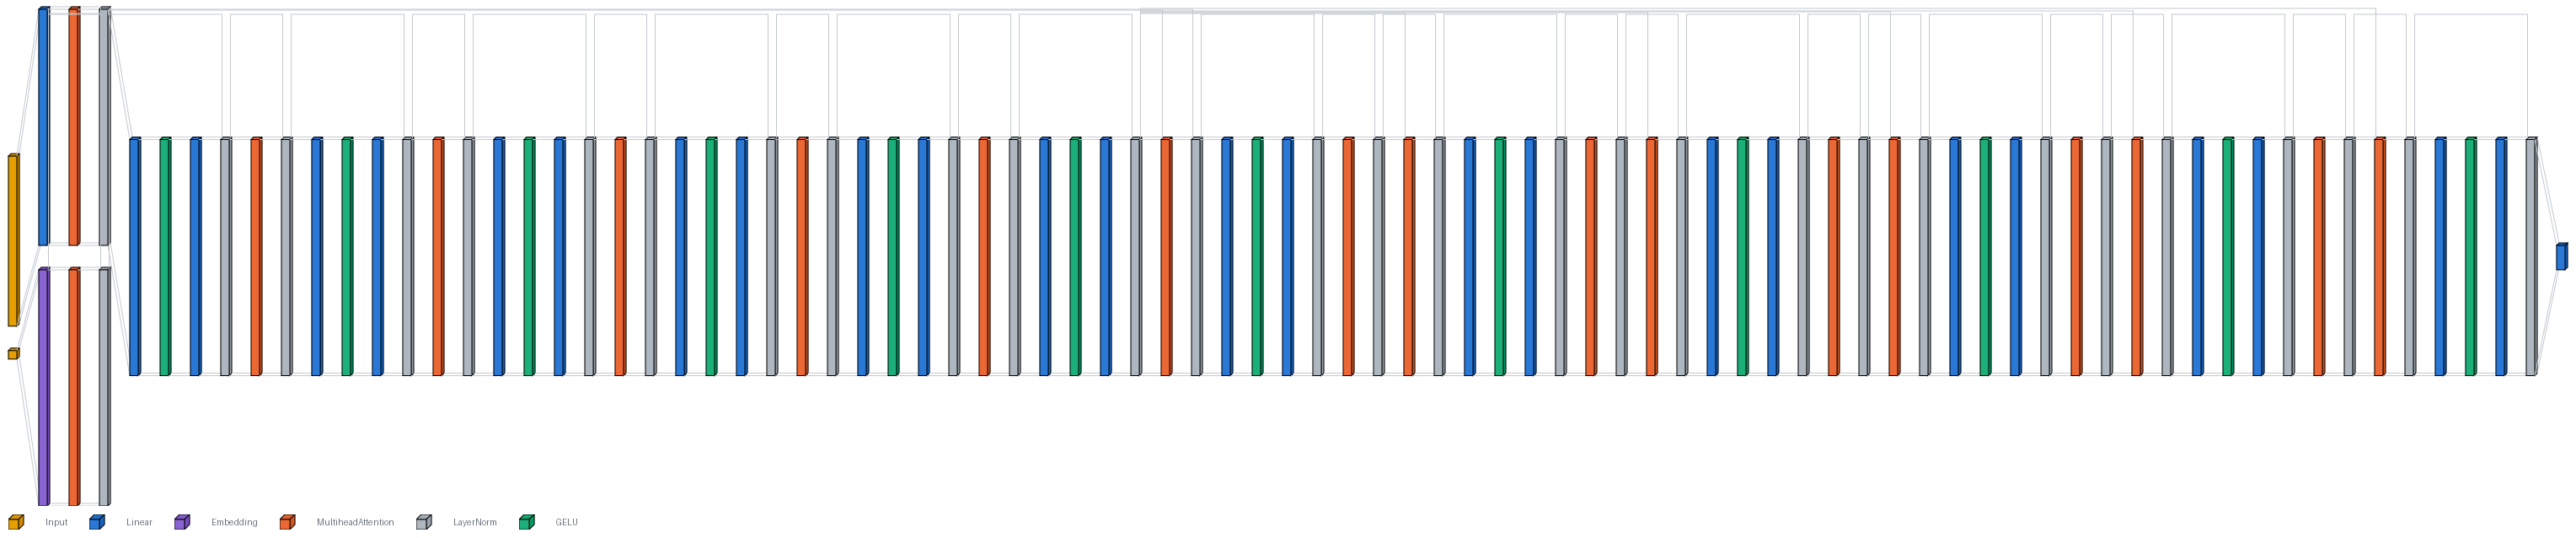

In [5]:
#| label: fig-arch
#| fig-cap: The encoder-decoder. Two inputs, two stacks, joined by the decoder's cross-attention.
#| fig-alt: A diagram with two input streams on the left, one from an image and one through an embedding, running through repeated blocks and converging into a single column on the right.

diagram(Reader(), input_shape=((1, 28, 84), (1, L + 1)), style="flow",
        input_dtype=(torch.float32, torch.long))

So the model below is built with two ways to run it: one for training, and one for
measuring, which generates a digit at a time from the model's own output the way
inference has to.


In [6]:
torch.manual_seed(0)
model = Reader().to(DEVICE)
optimiser = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
generator = torch.Generator().manual_seed(0)

@torch.no_grad()
def generate():
    """One token at a time from the model's own output, as at inference."""
    tokens = torch.full((len(X_test), 1), START, device=DEVICE)
    memory = model.encode(X_test)
    for _ in range(L + 1):                  # three digits, and then <end>
        nxt = model.decode(memory, tokens)[0][:, -1].argmax(-1, keepdim=True)
        tokens = torch.cat([tokens, nxt], dim=1)
    return tokens[:, 1:]

def exact_sequence():
    """Correct means the right digits, and <end> in the right place.

    A three-digit answer to a two-digit image is wrong however good the digits are,
    so length is scored, not assumed.
    """
    out = generate()
    wanted = target_test
    scored = wanted != PAD                      # nothing after <end> is scored
    return ((out == wanted) | ~scored).all(1).float().mean().item()

print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

11,091,468 parameters


Fifteen epochs, reporting after each how often a held-out image is read exactly
right: every digit correct, and the end token in the right place.

In [7]:
EPOCHS, BATCH, LABEL_SMOOTHING, CLIP = 15, 64, 0.1, 1.0

history = []
print(f"{'epoch':>6} {'read exactly right':>20}")
for epoch in range(EPOCHS):
    perm = torch.randperm(len(X), generator=generator).to(DEVICE)
    for i in range(0, len(perm) - BATCH, BATCH):
        b = perm[i:i + BATCH]
        logits = model(X[b], decoder_input[b])
        loss = nn.functional.cross_entropy(logits.reshape(-1, VOCAB),
                                           decoder_target[b].reshape(-1),
                                           ignore_index=PAD,
                                           label_smoothing=LABEL_SMOOTHING)
        optimiser.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimiser.step()
    history.append(exact_sequence())
    print(f"{epoch + 1:>6} {history[-1]:>19.1%}")

 epoch   read exactly right


     1               88.5%


     2               94.0%


     3               94.1%


     4               94.6%


...

    11               95.8%


    12               95.2%


    13               95.7%


    14               95.7%


    15               95.4%


Most held-out images read exactly right, against one in a thousand for guessing.

The column is bumpier than a training loss would be, and that is the measure rather
than the model: one wrong digit early in a sequence takes the whole sequence with
it, so a small change in per-digit accuracy moves this number three times as far.

## What It Learned on Its Own

**Nobody told this model the digits run left to right.**

The encoder produces 48 patch tokens in a 4×12 grid. The decoder generates three
outputs. Which patches does each output position attend to?

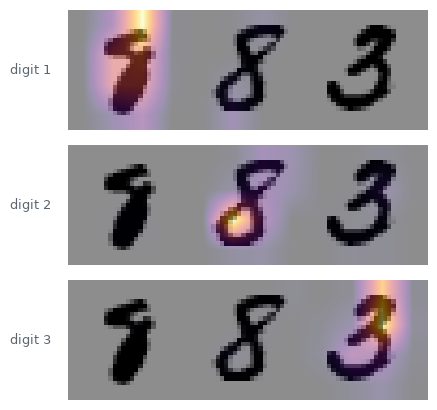

In [8]:
#| label: fig-cross
#| fig-cap: Cross-attention from each output position onto the image patches. The alignment is learned, not specified.
#| fig-alt: Three copies of the same wide three-digit image, each with a heat overlay. The first is bright over the leftmost digit, the second over the middle digit, the third over the rightmost.

with torch.no_grad():
    full = int((counts_test == L).nonzero()[0])     # a three-digit canvas
    memory = model.encode(X_test[full:full + 1])
    tokens = torch.cat([torch.full((1, 1), START, device=DEVICE),
                        Y_test[full:full + 1]], dim=1)
    _, weights = model.decode(memory, tokens, want_weights=True)

attention = weights[0].reshape(-1, *GRID).cpu()   # one map per output position

fig, axes = plt.subplots(3, 1, figsize=(7.4, 4.2))
for position, ax in enumerate(axes):
    ax.imshow(X_test[full].cpu(), cmap="gray_r")
    ax.imshow(attention[position], cmap="inferno", alpha=0.45,
              extent=(0, 84, 28, 0), interpolation="bilinear")
    ax.set_ylabel(f"digit {position + 1}", color=MUTED, fontsize=9, rotation=0,
                  ha="right", va="center", labelpad=12)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
fig.tight_layout()

Putting numbers on that: the share of each output position's attention landing in
each third of the image.

In [9]:
print("share of each output's attention falling on each third of the image\n")
print(f"{'':10} {'left':>8} {'middle':>8} {'right':>8}")
for position in range(L):
    by_column = attention[position].sum(0)
    thirds = [by_column[i:i + 4].sum() / by_column.sum() for i in (0, 4, 8)]
    print(f"digit {position + 1:<4} " + "".join(f"{t:>8.2f}" for t in thirds))

share of each output's attention falling on each third of the image

               left   middle    right
digit 1        0.90    0.10    0.00
digit 2        0.05    0.79    0.17
digit 3        0.00    0.05    0.94


Each output position learns to look at its own third of the image. The loss never
mentions position. It only ever says *the first digit is a 7*. The alignment
between output order and image geometry is something the model works out because
it's the only way to get the answer right.

The same mechanism makes translation work. There the alignment is between words in
two languages rather than positions in an image. It's why cross-attention replaced
the fixed-size context vector that encoder-decoders used before it.

## Conclusion

A decoder is not a bigger classifier. It is a different contract.

* The model commits to one token
* It then conditions on its own commitment
* Errors compound down the sequence
* Teacher forcing hides all of that during training

Which is why the number that matters has to be generated the slow way.

One consequence of generating a token at a time is that you can watch it happen.
The service streams each digit the moment the decoder emits it, so the page shows
the number being read rather than appearing at once. That is not a UI flourish, it
is what the architecture does, made visible.

## Where this goes

The week ends by pointing the same encoder-decoder at something that is not an
image at all.

![](figures/audio.png){fig-alt="The same encoder-decoder stack, but with a waveform entering through a 1-D convolution on the left and MIDI notation coming out of the decoder on the right."}

Swap the patch projection for a convolution over a waveform and the decoder now
writes music notation. Nothing in the middle changed. That is the same point the
[Encoders slide](../2026-06-22-vision-transformers/) made, and it is what
[week 5](../2026-07-06-fine-tuning-whisper/) is built on.

The full project is
[on GitHub](https://github.com/RoshBeed/ai-residency/tree/main/services/vit-seq2seq).
